Saving BTCUSDT_Trades_1Hour.csv to BTCUSDT_Trades_1Hour.csv
Number of durations: 32454

Estimated Parameters
---------------------
Omega : 0.0032232139640385664
Alpha : 0.3302148717815871
Beta  : 0.669782383156167


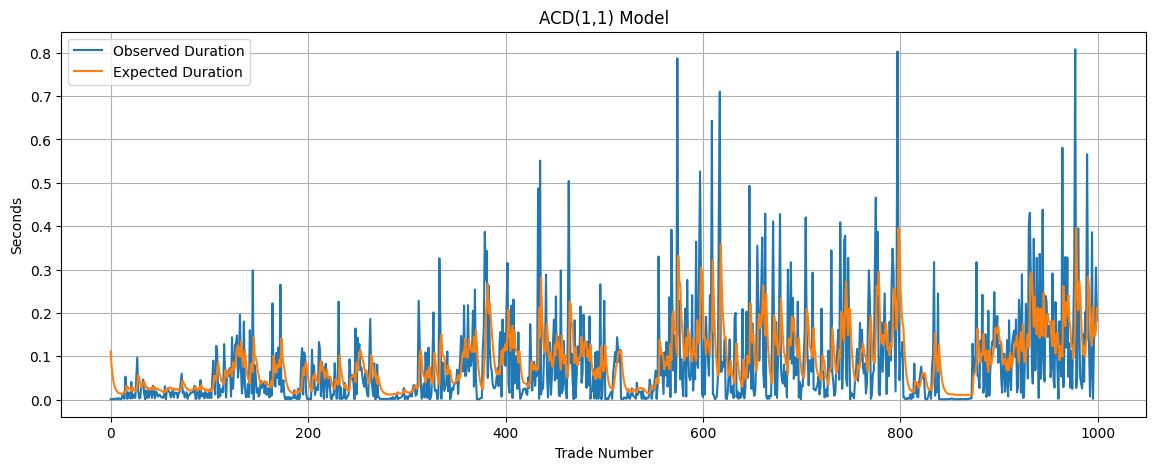

In [1]:
# ===========================================
# ACD(1,1) Model for BTCUSDT Trade Durations
# ===========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -----------------------------
# Load Data
# -----------------------------
from google.colab import files

uploaded = files.upload()

trades = pd.read_csv("BTCUSDT_Trades_1Hour.csv")

# -----------------------------
# Convert Timestamp
# -----------------------------
trades["timestamp"] = pd.to_datetime(trades["timestamp"])

trades = trades.sort_values("timestamp")

# -----------------------------
# Compute Durations (seconds)
# -----------------------------
trades["duration"] = (
    trades["timestamp"]
    .diff()
    .dt.total_seconds()
)

trades = trades.dropna()

# Remove zero durations
trades = trades[trades["duration"] > 0]

durations = trades["duration"].values

print("Number of durations:", len(durations))

# -----------------------------
# ACD Log-Likelihood
# -----------------------------
def negative_loglik(params):

    omega, alpha, beta = params

    # Stationarity
    if omega <= 0 or alpha < 0 or beta < 0 or alpha + beta >= 1:
        return 1e10

    n = len(durations)

    psi = np.zeros(n)

    psi[0] = np.mean(durations)

    for t in range(1, n):

        psi[t] = (
            omega
            + alpha * durations[t-1]
            + beta * psi[t-1]
        )

    loglik = np.sum(
        np.log(psi)
        + durations / psi
    )

    return loglik

# -----------------------------
# Estimate Parameters
# -----------------------------
initial = [0.01,0.10,0.80]

result = minimize(
    negative_loglik,
    initial,
    method="L-BFGS-B"
)

omega, alpha, beta = result.x

print("\nEstimated Parameters")
print("---------------------")
print("Omega :", omega)
print("Alpha :", alpha)
print("Beta  :", beta)

# -----------------------------
# Expected Durations
# -----------------------------
psi = np.zeros(len(durations))

psi[0] = np.mean(durations)

for t in range(1,len(durations)):

    psi[t] = (
        omega
        + alpha*durations[t-1]
        + beta*psi[t-1]
    )

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(14,5))

plt.plot(
    durations[:1000],
    label="Observed Duration"
)

plt.plot(
    psi[:1000],
    label="Expected Duration"
)

plt.legend()

plt.title("ACD(1,1) Model")

plt.xlabel("Trade Number")

plt.ylabel("Seconds")

plt.grid(True)

plt.show()